In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")

 DATA COLLECTION

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/AmesHousing.csv")

print(f"Dataset shape: {df.shape}")
print(f"\nFirst 5 rows:")
print(df.head())

print(f"\nColumn names:")
print(df.columns.tolist())

print(f"\nTarget variable (SalePrice) stats:")
print(df["SalePrice"].describe())

Dataset shape: (2930, 82)

First 5 rows:
   Order        PID  MS SubClass MS Zoning  Lot Frontage  Lot Area Street  \
0      1  526301100           20        RL         141.0     31770   Pave   
1      2  526350040           20        RH          80.0     11622   Pave   
2      3  526351010           20        RL          81.0     14267   Pave   
3      4  526353030           20        RL          93.0     11160   Pave   
4      5  527105010           60        RL          74.0     13830   Pave   

  Alley Lot Shape Land Contour  ... Pool Area Pool QC  Fence Misc Feature  \
0   NaN       IR1          Lvl  ...         0     NaN    NaN          NaN   
1   NaN       Reg          Lvl  ...         0     NaN  MnPrv          NaN   
2   NaN       IR1          Lvl  ...         0     NaN    NaN         Gar2   
3   NaN       Reg          Lvl  ...         0     NaN    NaN          NaN   
4   NaN       IR1          Lvl  ...         0     NaN  MnPrv          NaN   

  Misc Val Mo Sold Yr Sold Sale T

EDA & PREPROCESSING

In [ ]:
print("\n--- Missing Values (top 15) ---")
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({"Missing Count": missing, "Missing %": missing_pct})
print(missing_df[missing_df["Missing Count"] > 0].head(15))


--- Missing Values (top 15) ---
                Missing Count  Missing %
Pool QC                  2917      99.56
Misc Feature             2824      96.38
Alley                    2732      93.24
Fence                    2358      80.48
Mas Vnr Type             1775      60.58
Fireplace Qu             1422      48.53
Lot Frontage              490      16.72
Garage Qual               159       5.43
Garage Yr Blt             159       5.43
Garage Cond               159       5.43
Garage Finish             159       5.43
Garage Type               157       5.36
Bsmt Exposure              83       2.83
BsmtFin Type 2             81       2.76
Bsmt Qual                  80       2.73


In [ ]:
# Drop columns with >40% missing data
threshold = 0.4 * len(df)
df = df.dropna(thresh=threshold, axis=1)

In [ ]:
# Fill remaining numeric NaN with median
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

In [ ]:
# Fill remaining categorical NaN with mode
cat_cols = df.select_dtypes(include=["object"]).columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])
print(f"\nMissing values after cleaning: {df.isnull().sum().sum()}")


Missing values after cleaning: 0


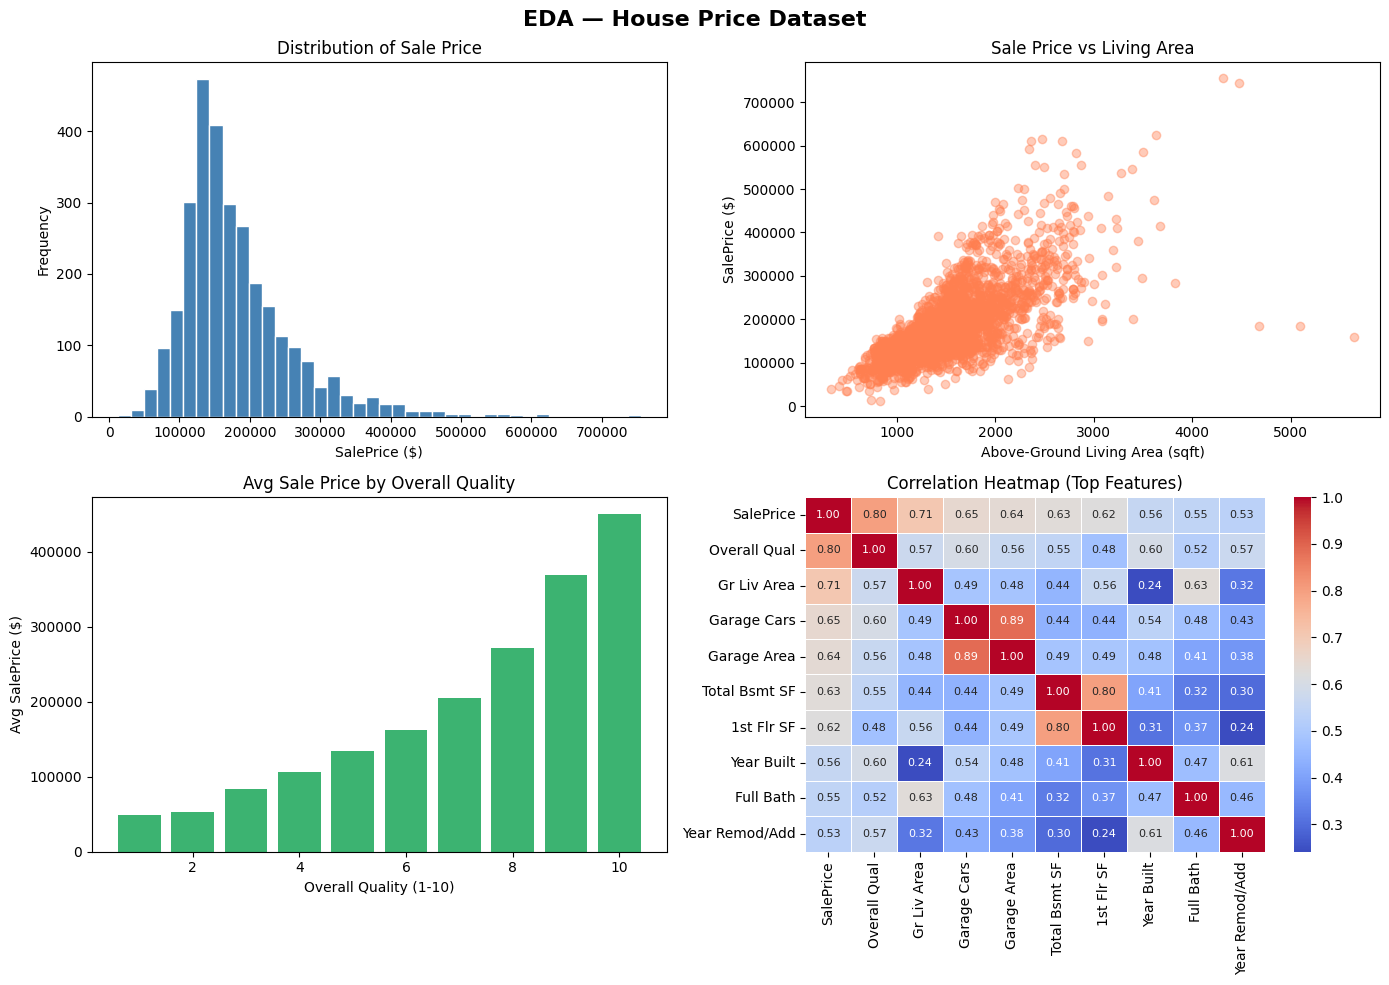


✅ EDA plots saved as 'eda_plots.png'


In [ ]:
# --- 4b. EDA Visualizations ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("EDA — House Price Dataset", fontsize=16, fontweight="bold")

# Distribution of SalePrice
axes[0, 0].hist(df["SalePrice"], bins=40, color="steelblue", edgecolor="white")
axes[0, 0].set_title("Distribution of Sale Price")
axes[0, 0].set_xlabel("SalePrice ($)")
axes[0, 0].set_ylabel("Frequency")

# SalePrice vs GrLivArea
axes[0, 1].scatter(df["Gr Liv Area"], df["SalePrice"], alpha=0.4, color="coral")
axes[0, 1].set_title("Sale Price vs Living Area")
axes[0, 1].set_xlabel("Above-Ground Living Area (sqft)")
axes[0, 1].set_ylabel("SalePrice ($)")

# SalePrice vs OverallQual
avg_price_by_qual = df.groupby("Overall Qual")["SalePrice"].mean()
axes[1, 0].bar(avg_price_by_qual.index, avg_price_by_qual.values, color="mediumseagreen")
axes[1, 0].set_title("Avg Sale Price by Overall Quality")
axes[1, 0].set_xlabel("Overall Quality (1-10)")
axes[1, 0].set_ylabel("Avg SalePrice ($)")

# Correlation heatmap (top numeric features)
top_corr_cols = df[numeric_cols].corr()["SalePrice"].abs().sort_values(ascending=False).head(10).index
corr_matrix = df[top_corr_cols].corr()
sns.heatmap(corr_matrix, ax=axes[1, 1], annot=True, fmt=".2f",
            cmap="coolwarm", linewidths=0.5, annot_kws={"size": 8})
axes[1, 1].set_title("Correlation Heatmap (Top Features)")

plt.tight_layout()
plt.savefig("eda_plots.png", dpi=150)
plt.show()
print("\n✅ EDA plots saved as 'eda_plots.png'")

Feature Selection

In [ ]:
# Select the most correlated numeric features
corr_with_price = df[numeric_cols].corr()["SalePrice"].abs().sort_values(ascending=False)
top_features = corr_with_price[1:11].index.tolist()  # top 10 (exclude SalePrice itself)
print(f"\nTop 10 correlated features:\n{corr_with_price[1:11]}")


Top 10 correlated features:
Overall Qual      0.799262
Gr Liv Area       0.706780
Garage Cars       0.647812
Garage Area       0.640381
Total Bsmt SF     0.632164
1st Flr SF        0.621676
Year Built        0.558426
Full Bath         0.545604
Year Remod/Add    0.532974
Garage Yr Blt     0.508882
Name: SalePrice, dtype: float64


In [ ]:
# Encode Categorical Variables
df_model = df[top_features + ["SalePrice"]].copy()

In [ ]:
# Add a useful categorical: Neighborhood
df_model["Neighborhood"] = df["Neighborhood"]
le = LabelEncoder()
df_model["Neighborhood"] = le.fit_transform(df_model["Neighborhood"])

In [ ]:
# Feature Scaling
X = df_model.drop("SalePrice", axis=1)
y = df_model["SalePrice"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Train-Test Split (80/20)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)
print(f"Train set: {X_train.shape[0]} rows")
print(f"Test set:  {X_test.shape[0]} rows")


Train set: 2344 rows
Test set:  586 rows


MODEL BUILDING

In [ ]:
# Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
print("✅ Linear Regression trained.")

✅ Linear Regression trained.


In [ ]:
# Beyond: Ridge & Lasso (regularized regression)
ridge_model = Ridge(alpha=10)
ridge_model.fit(X_train, y_train)
print("✅ Ridge Regression trained.")

lasso_model = Lasso(alpha=10)
lasso_model.fit(X_train, y_train)
print("✅ Lasso Regression trained.")

✅ Ridge Regression trained.
✅ Lasso Regression trained.


MODEL EVALUATION

In [ ]:
def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    r2   = r2_score(y_test, y_pred)
    mse  = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    print(f"\n📊 {name}")
    print(f"   R²   : {r2:.4f}")
    print(f"   MSE  : ${mse:,.2f}")
    print(f"   RMSE : ${rmse:,.2f}")
    return y_pred, r2, rmse

lr_preds,    lr_r2,    lr_rmse    = evaluate_model("Linear Regression", lr_model,    X_test, y_test)
ridge_preds, ridge_r2, ridge_rmse = evaluate_model("Ridge Regression",  ridge_model, X_test, y_test)
lasso_preds, lasso_r2, lasso_rmse = evaluate_model("Lasso Regression",  lasso_model, X_test, y_test)


📊 Linear Regression
   R²   : 0.8083
   MSE  : $1,536,946,454.53
   RMSE : $39,203.91

📊 Ridge Regression
   R²   : 0.8082
   MSE  : $1,537,840,860.56
   RMSE : $39,215.31

📊 Lasso Regression
   R²   : 0.8083
   MSE  : $1,537,178,529.91
   RMSE : $39,206.87


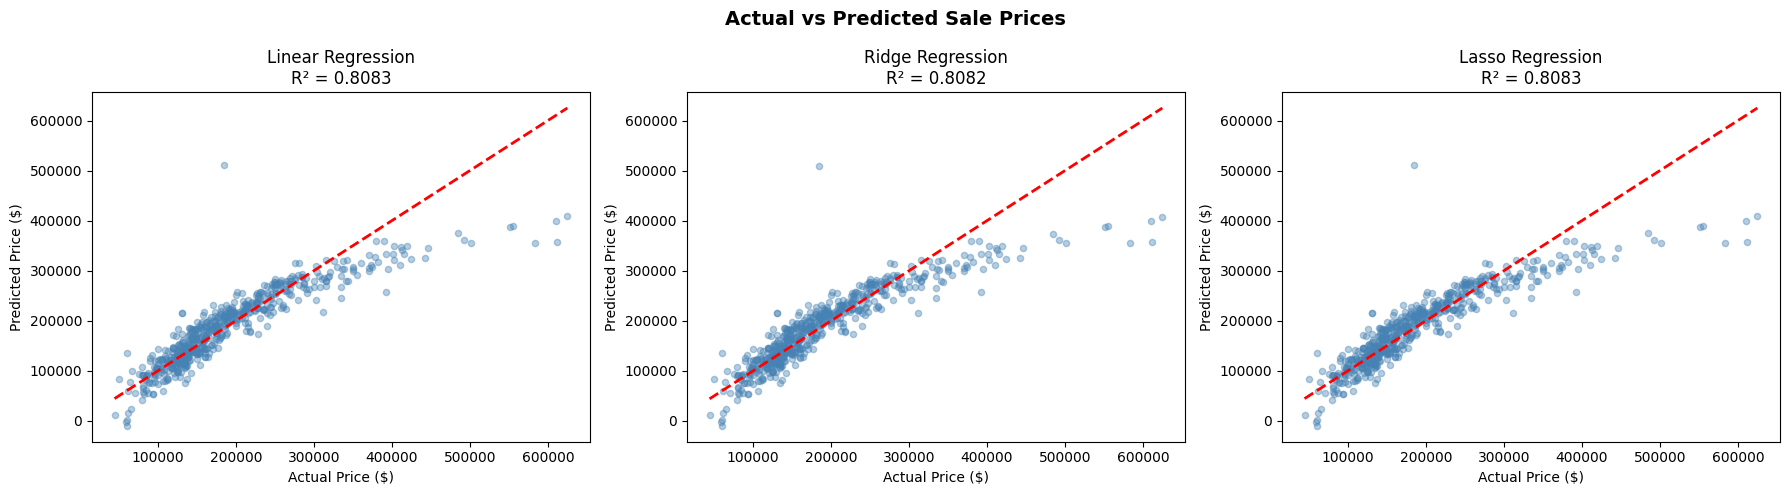


✅ Evaluation plots saved as 'model_evaluation.png'


In [ ]:
# --- Actual vs Predicted Plot ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Actual vs Predicted Sale Prices", fontsize=14, fontweight="bold")

for ax, preds, name, r2 in zip(
    axes,
    [lr_preds, ridge_preds, lasso_preds],
    ["Linear Regression", "Ridge Regression", "Lasso Regression"],
    [lr_r2, ridge_r2, lasso_r2]
):
    ax.scatter(y_test, preds, alpha=0.4, color="steelblue", s=20)
    ax.plot([y_test.min(), y_test.max()],
            [y_test.min(), y_test.max()], "r--", linewidth=2)
    ax.set_title(f"{name}\nR² = {r2:.4f}")
    ax.set_xlabel("Actual Price ($)")
    ax.set_ylabel("Predicted Price ($)")

plt.tight_layout()
plt.savefig("model_evaluation.png", dpi=150)
plt.show()
print("\n✅ Evaluation plots saved as 'model_evaluation.png'")


--- Linear Regression Feature Coefficients ---
       Feature  Coefficient
  Overall Qual 27692.240113
   Gr Liv Area 26114.770909
    Year Built  9089.746762
 Total Bsmt SF  8301.899594
Year Remod/Add  6371.633764
    1st Flr SF  5629.329190
   Garage Cars  5381.672844
   Garage Area  4920.200165
  Neighborhood  1757.832377
 Garage Yr Blt   417.056092
     Full Bath -4855.913253


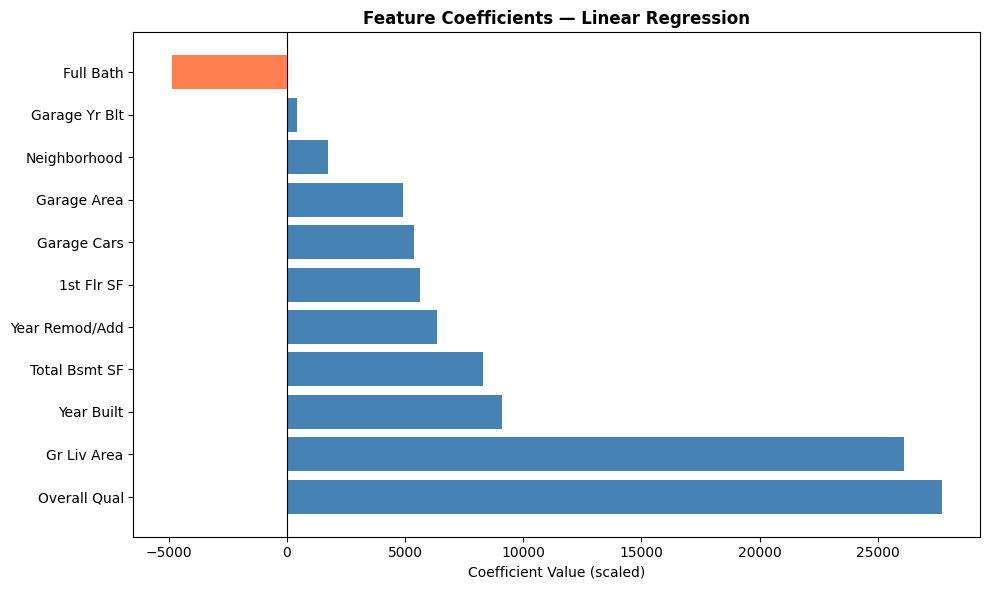

✅ Feature importance plot saved as 'feature_importance.png'


In [ ]:
# --- Feature Importance (Linear Regression Coefficients) ---
feature_names = X.columns.tolist()
coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": lr_model.coef_
}).sort_values("Coefficient", ascending=False)

print("\n--- Linear Regression Feature Coefficients ---")
print(coef_df.to_string(index=False))

plt.figure(figsize=(10, 6))
colors = ["steelblue" if c > 0 else "coral" for c in coef_df["Coefficient"]]
plt.barh(coef_df["Feature"], coef_df["Coefficient"], color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Feature Coefficients — Linear Regression", fontweight="bold")
plt.xlabel("Coefficient Value (scaled)")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150)
plt.show()
print("✅ Feature importance plot saved as 'feature_importance.png'")